# **Tutorial 08 - Curve Fitting**: Supplementary Interactive Material

-------------------------------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit


# Michaelis–Menten Parameter Estimation
## Linearization vs Nonlinear Least Squares (NLS)

In this notebook, we compare two approaches to fitting the Michaelis–Menten model, for reaction rate proportional to available substrate:

$$
V = \frac{V_{\max} S}{K_m + S}
$$

- **Linearization (Lineweaver–Burk):**
  Transform to a linear form using:
  $$
  \frac{1}{V} = \frac{K_m}{V_{\max}} \cdot \frac{1}{S} + \frac{1}{V_{\max}}
  $$
  Then apply simple linear regression.

- **Nonlinear Least Squares (NLS):**
  Fit directly to the original nonlinear model by minimizing:
  $$
  \sum_i \left( V_i - \frac{V_{\max} S_i}{K_m + S_i} \right)^2
  $$

We will compute parameter estimates, compare models, and analyze their fitting errors.


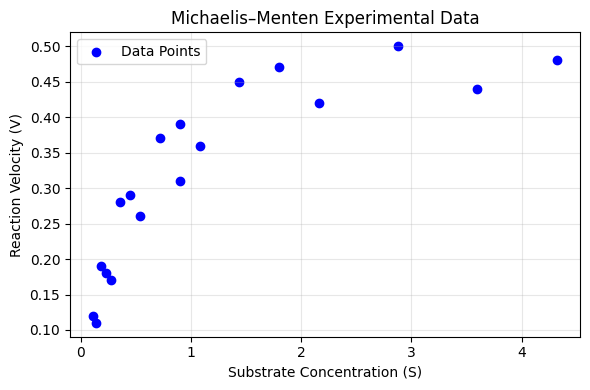

In [2]:
# Given Data
S = np.array([4.32, 2.16, 1.08, 0.54, 0.27, 0.135, 3.6, 1.8, 0.9, 0.45,
              0.225, 0.1125, 2.88, 1.44, 0.72, 0.36, 0.18, 0.9, 0])
V = np.array([0.48, 0.42, 0.36, 0.26, 0.17, 0.11, 0.44, 0.47, 0.39,
              0.29, 0.18, 0.12, 0.5, 0.45, 0.37, 0.28, 0.19, 0.31, 0])

mask = (S > 0) & (V > 0)
S_nonzero = S[mask]
V_nonzero = V[mask]

plt.figure(figsize=(6, 4))
plt.scatter(S_nonzero, V_nonzero, color='blue', label='Data Points')
plt.xlabel("Substrate Concentration (S)")
plt.ylabel("Reaction Velocity (V)")
plt.title("Michaelis–Menten Experimental Data")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## a). Linearization (Lineweaver–Burk Method)

Using the reciprocal transformation:

$$
\frac{1}{V} = \frac{K_m}{V_{\max}}\cdot \frac{1}{S} + \frac{1}{V_{\max}}
$$

This allows us to estimate slope and intercept using linear regression:
- Slope = $ K_m / V_{\max} $
- Intercept = $ 1 / V_{\max} $


Linearization Estimates:
  Vmax = 0.5272
  Km   = 0.4223


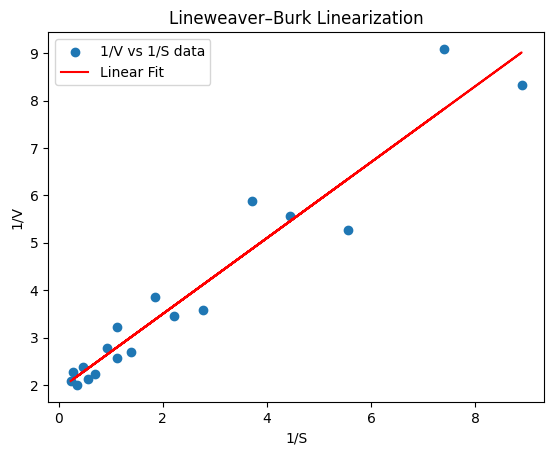

In [3]:
# Linearization
x = 1 / S_nonzero
y = 1 / V_nonzero
slope, intercept, r, p, se = linregress(x, y)

Vmax_lin = 1 / intercept
Km_lin = slope / intercept

print(f"Linearization Estimates:")
print(f"  Vmax = {Vmax_lin:.4f}")
print(f"  Km   = {Km_lin:.4f}")

# Plot
plt.scatter(x, y, label="1/V vs 1/S data")
plt.plot(x, slope*x + intercept, color='red', label="Linear Fit")
plt.xlabel("1/S")
plt.ylabel("1/V")
plt.title("Lineweaver–Burk Linearization")
plt.legend()
plt.show()


### b). Nonlinear Least Squares (NLS) — What Is Actually Happening?

Instead of linearizing the Michaelis–Menten equation, we directly fit the original nonlinear model:

$$
V(S; V_{\max}, K_m) = \frac{V_{\max} S}{K_m + S}
$$

We find parameters $(V_{\max}, K_m)$ that minimize the sum of squared errors:

$$
J(V_{\max}, K_m) = \sum_{i=1}^n \left[ V_i - \frac{V_{\max} S_i}{K_m + S_i} \right]^2
$$

Because this function is **nonlinear in the parameters**, there is no closed-form solution.  
We must solve it **iteratively**:

**A simple approach would be:**

1. Choose an initial guess $(V_{\max}^{(0)}, K_m^{(0)})$
2. Compute residuals: $r_i = V_i - f(S_i; \theta)$
3. Compute gradient of $J$ with respect to parameters
4. Update parameters using:
   $$
   \theta^{(k+1)} = \theta^{(k)} - \alpha \nabla J(\theta^{(k)})
   $$
   (Gradient Descent)

**In practice**, most software (e.g. `scipy.curve_fit`) uses the **Levenberg–Marquardt algorithm**, which updates:

$$
(\mathbf{J}^T \mathbf{J} + \lambda I)\Delta\theta = \mathbf{J}^T r
$$

This method balances **speed** (Gauss–Newton) and **stability** (Gradient Descent).

For the sake of this demonstration, we will use `scipy.curve_fit`


NLS Estimates:
  Vmax = 0.5332
  Km   = 0.4187

Model Fit (Sum of Squared Errors):
  Linearized Fit SSE = 0.0176
  NLS Fit SSE       = 0.0172


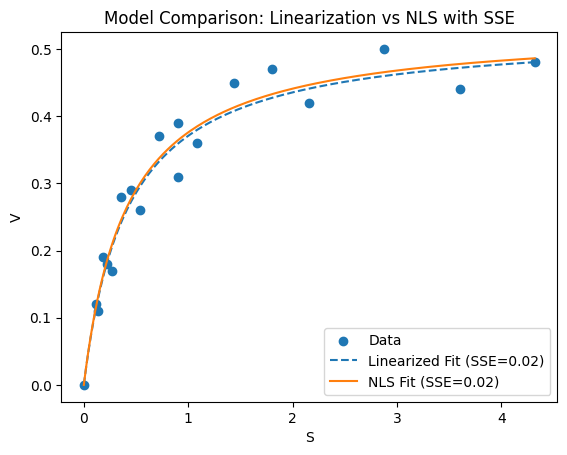

In [4]:

# Michaelis-Menten model
def MM(S, Vmax, Km):
    return (Vmax * S) / (Km + S)

# Fit using Nonlinear Least Squares (NLS)
popt, _ = curve_fit(MM, S_nonzero, V_nonzero, p0=[Vmax_lin, Km_lin])
Vmax_nls, Km_nls = popt

# Predictions
V_pred_lin = MM(S, Vmax_lin, Km_lin)
V_pred_nls = MM(S, Vmax_nls, Km_nls)

# --- Sum of Squared Errors (SSE) ---
SSE_lin = np.sum((V - V_pred_lin)**2)
SSE_nls = np.sum((V - V_pred_nls)**2)

print(f"NLS Estimates:")
print(f"  Vmax = {Vmax_nls:.4f}")
print(f"  Km   = {Km_nls:.4f}")
print("\nModel Fit (Sum of Squared Errors):")
print(f"  Linearized Fit SSE = {SSE_lin:.4f}")
print(f"  NLS Fit SSE       = {SSE_nls:.4f}")

# Plot Fits
S_fit = np.linspace(0, max(S), 200)
plt.scatter(S, V, label="Data")
plt.plot(S_fit, MM(S_fit, Vmax_lin, Km_lin), '--', label=f"Linearized Fit (SSE={SSE_lin:.2f})")
plt.plot(S_fit, MM(S_fit, Vmax_nls, Km_nls), label=f"NLS Fit (SSE={SSE_nls:.2f})")
plt.xlabel("S")
plt.ylabel("V")
plt.title("Model Comparison: Linearization vs NLS with SSE")
plt.legend()
plt.show()